In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from data_processing import WoodIndustryDataProcessor
from analyzer import WoodIndustryAnalyzer

In [2]:
processor = WoodIndustryDataProcessor('продукция_выручка2.xlsx')
df = processor.run_full_preprocessing()

Топ-10 ключевых слов:
   доска: 18 раз
   брус: 13 раз
   плита: 8 раз
   профиля: 8 раз
   древесноволокнистая: 7 раз
   бруса: 7 раз
   заполнение: 7 раз
   проекту: 7 раз
   фанера: 7 раз
   имитация: 6 раз

ПРИМЕРЫ ПО КАТЕГОРИЯМ:

ПИЛОМАТЕРИАЛЫ:
   • Брус клееный 100x100 мм
   • Доска строганная 50x150x6000 мм
   • Имитация бруса 21x146 мм

ПЛИТЫ:
   • Древесноволокнистая плита, шлифованная, 16 мм
   • Древесноволокнистая плита, шлифованная, 18 мм
   • Древесноволокнистая плита, ламинированная "Дуб", 16 мм

ОТДЕЛОЧНЫЕ_МАТЕРИАЛЫ:
   • Вагонка Штиль 12,5x96 мм
   • Блок-Хаус 36x190 мм
   • Планкен фасадный из лиственницы 20x70 мм

ПРОЧЕЕ:
   • Оцилиндрованное бревно 240 мм
   • Рейка обрешетки 30x50 мм
   • Древесная масса

ЦЕЛЛЮЛОЗА_БУМАГА:
   • Целлюлоза беленая хвойная
   • Целлюлоза беленая лиственная
   • Картон гофрированный

СТРОИТЕЛЬНЫЕ_КОНСТРУКЦИИ:
   • Домокомплект "Дачный" (каркас)
   • Домокомплект "Баня" (сруб)
   • Балка клееная 100x200x6000 мм

ОКНА_ДВЕРИ:
   • Блоки о

Ранжирование компаний и общая статистика


 ТОП-10 КОМПАНИЙ ПО ПРИБЫЛЬНОСТИ:
 1. Илим                 | Прибыль: 50,332,047,000 руб | Рентабельность:  26.2%
 2. МДФ                  | Прибыль:  533,736,000 руб | Рентабельность:  29.8%
 3. Енисей               | Прибыль:  474,244,333 руб | Рентабельность:  15.6%
 4. Онежский компбинат   | Прибыль:  472,342,000 руб | Рентабельность:  13.4%
 5. Сокольский комбинат  | Прибыль:  317,631,667 руб | Рентабельность:   6.8%
 6. ВЛПХ                 | Прибыль:  147,858,333 руб | Рентабельность:   8.1%
 7. Аргус-Волга          | Прибыль:  105,433,667 руб | Рентабельность:   6.7%
 8. Н.М комбинат         | Прибыль:   50,777,333 руб | Рентабельность:   7.0%
 9. Лестех               | Прибыль:    1,022,000 руб | Рентабельность:  32.4%
10. ИвДревПлит           | Прибыль:      787,667 руб | Рентабельность:   1.8%


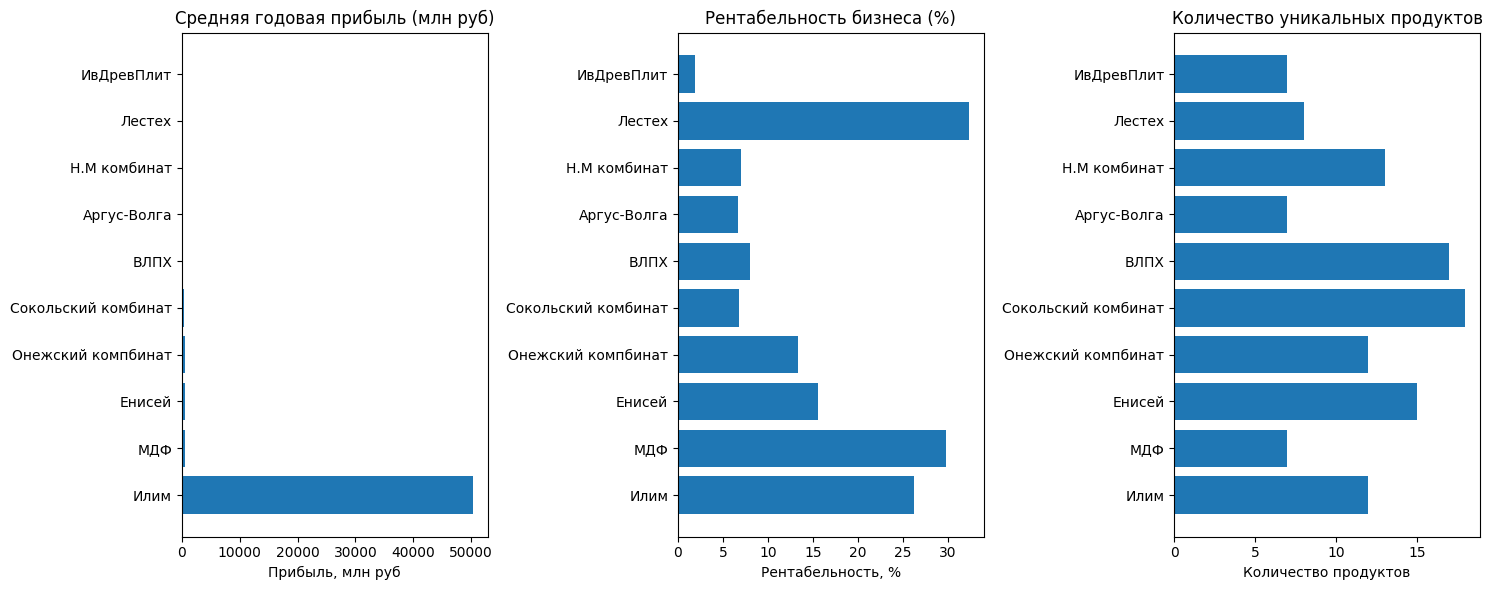

In [18]:
metrics = processor.calculate_company_metrics()

if metrics is not None:
    print("\n ТОП-10 КОМПАНИЙ ПО ПРИБЫЛЬНОСТИ:")
    print("=" * 50)
    
    top_companies = metrics.head(10)
    for i, (_, company) in enumerate(top_companies.iterrows(), 1):
        print(f"{i:2d}. {company['компания']:20} | "
              f"Прибыль: {company['годовая_прибыль_руб_mean']:>12,.0f} руб | "
              f"Рентабельность: {company['рентабельность']:>5.1f}%")
    
    # Визуализация рейтинга
    analyzer = WoodIndustryAnalyzer(df)
    analyzer.plot_company_ranking(metrics)


In [17]:
def analyze_company_sales(company_name):
    """Анализ продаж конкретной компании"""
    company_data = df[df['компания'] == company_name]
    
    print(f"\n КОМПАНИЯ: {company_name}")
    print("-" * 40)
    
    total_revenue = company_data['выручка_руб'].sum()
    total_volume = company_data['количество_шт'].sum()
    avg_price = company_data['цена_руб'].mean()
    
    print(f" Общая статистика:")
    print(f"   • Выручка: {total_revenue:,.0f} руб")
    print(f"   • Объем продаж: {total_volume:,.0f} шт")
    print(f"   • Средняя цена: {avg_price:,.0f} руб")
    print(f"   • Уникальных продуктов: {company_data['продукция'].nunique()}")
    print(f"   • Категорий: {company_data['категория_продукции'].nunique()}")
    
    print(f"\n ТОП-5 ПРОДУКТОВ ПО ВЫРУЧКЕ:")
    top_products = company_data.groupby('продукция').agg({
        'выручка_руб': 'sum',
        'количество_шт': 'sum', 
        'цена_руб': 'mean'
    }).sort_values('выручка_руб', ascending=False).head(5)
    
    for product, row in top_products.iterrows():
        print(f"   • {product}")
        print(f"     Цена: {row['цена_руб']:,.0f} руб | "
              f"Объем: {row['количество_шт']:,.0f} шт | "
              f"Выручка: {row['выручка_руб']:,.0f} руб")
    
    return company_data

Расширенная аналитика по ТОП-3 компаниям


 КОМПАНИЯ: Илим
----------------------------------------
 Общая статистика:
   • Выручка: 575,732,265,000 руб
   • Объем продаж: 8,074,111 шт
   • Средняя цена: 72,028 руб
   • Уникальных продуктов: 12
   • Категорий: 3

 ТОП-5 ПРОДУКТОВ ПО ВЫРУЧКЕ:
   • Целлюлоза беленая хвойная
     Цена: 86,000 руб | Объем: 1,948,461 шт | Выручка: 167,620,284,000 руб
   • Целлюлоза беленая лиственная
     Цена: 79,333 руб | Объем: 1,349,909 шт | Выручка: 107,156,428,000 руб
   • Картон гофрированный
     Цена: 66,167 руб | Объем: 1,137,897 шт | Выручка: 75,330,788,500 руб
   • Бумага газетная
     Цена: 56,333 руб | Объем: 652,836 шт | Выручка: 36,801,472,000 руб
   • Бумага офсетная
     Цена: 71,167 руб | Объем: 453,955 шт | Выручка: 32,327,887,500 руб

 ВИЗУАЛИЗАЦИЯ ДЛЯ Илим:


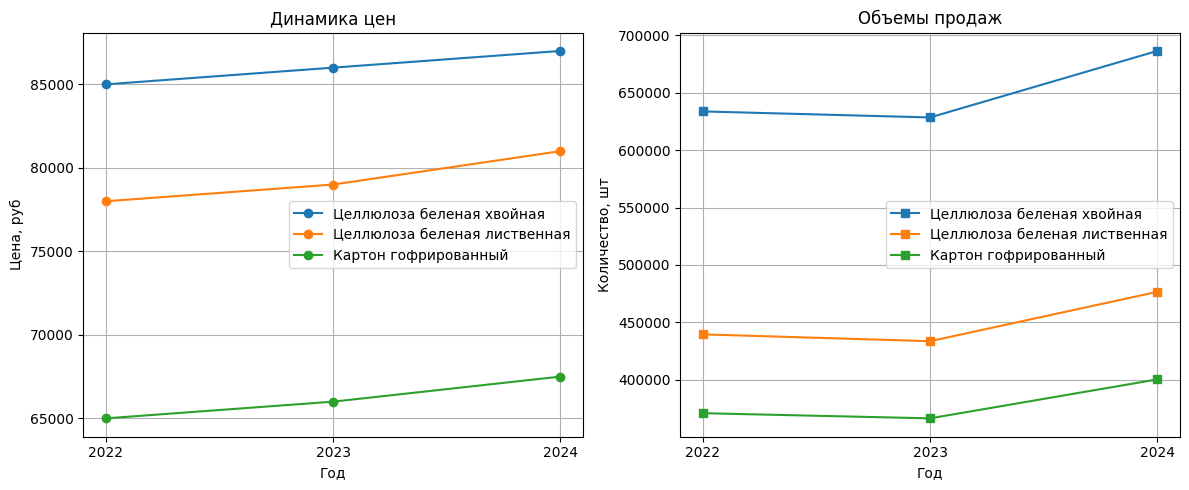


 КОМПАНИЯ: МДФ
----------------------------------------
 Общая статистика:
   • Выручка: 5,373,080,900 руб
   • Объем продаж: 857,428 шт
   • Средняя цена: 8,495 руб
   • Уникальных продуктов: 7
   • Категорий: 1

 ТОП-5 ПРОДУКТОВ ПО ВЫРУЧКЕ:
   • Древесноволокнистая плита, шлифованная, 16 мм
     Цена: 4,667 руб | Объем: 310,256 шт | Выручка: 1,434,637,500 руб
   • Древесноволокнистая плита, ламинированная "Дуб", 16 мм
     Цена: 8,267 руб | Объем: 164,882 шт | Выручка: 1,349,920,000 руб
   • Древесноволокнистая плита, шлифованная, 18 мм
     Цена: 5,167 руб | Объем: 222,947 шт | Выручка: 1,142,771,700 руб
   • Древесноволокнистая плита, ламинированная "Белый", 16 мм
     Цена: 8,467 руб | Объем: 87,450 шт | Выручка: 731,314,500 руб
   • Древесноволокнистая плита, крашенная белая, 19 мм
     Цена: 9,767 руб | Объем: 44,793 шт | Выручка: 431,782,000 руб

 ВИЗУАЛИЗАЦИЯ ДЛЯ МДФ:


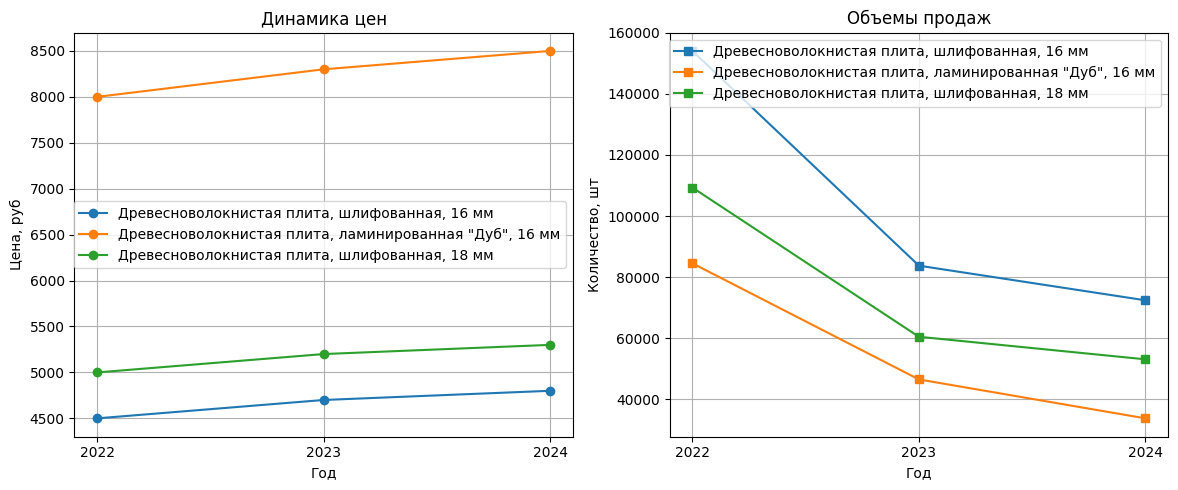


 КОМПАНИЯ: Енисей
----------------------------------------
 Общая статистика:
   • Выручка: 9,148,516,000 руб
   • Объем продаж: 289,838 шт
   • Средняя цена: 31,800 руб
   • Уникальных продуктов: 15
   • Категорий: 2

 ТОП-5 ПРОДУКТОВ ПО ВЫРУЧКЕ:
   • Блок-Хаус 36/28 х 185/135 мм.
     Цена: 32,000 руб | Объем: 19,060 шт | Выручка: 609,920,000 руб
   • Доска пола 21 х 115/90 мм.
     Цена: 32,000 руб | Объем: 19,060 шт | Выручка: 609,920,000 руб
   • Доска пола 28 х 135/115 мм.
     Цена: 32,000 руб | Объем: 19,060 шт | Выручка: 609,920,000 руб
   • Евровагонка 12,5 х 90 мм.
     Цена: 32,000 руб | Объем: 19,060 шт | Выручка: 609,920,000 руб
   • Вагонка Штиль 12,5 х 110/90 мм.
     Цена: 36,000 руб | Объем: 16,942 шт | Выручка: 609,912,000 руб

 ВИЗУАЛИЗАЦИЯ ДЛЯ Енисей:


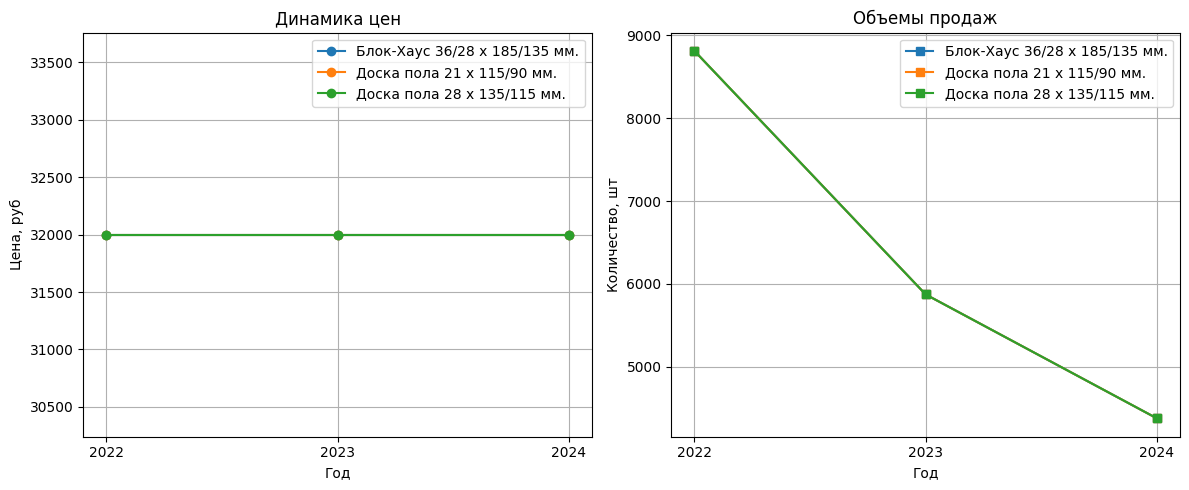

In [16]:
top_3_companies = metrics.head(3)['компания'].tolist()

for company in top_3_companies:
    analyze_company_sales(company)
    
    # Визуализация для топ компаний
    print(f"\n ВИЗУАЛИЗАЦИЯ ДЛЯ {company}:")
    analyzer.plot_price_dynamics(company_name=company)

In [20]:
def analyze_product_sales(product_name):
    """Анализ продаж конкретного продукта"""
    product_data = df[df['продукция'].str.contains(product_name, case=False, na=False)]
    
    
    print(f"\n ПРОДУКТ: {product_name}")
    print("-" * 40)
    
    total_revenue = product_data['выручка_руб'].sum()
    total_volume = product_data['количество_шт'].sum()
    avg_price = product_data['цена_руб'].mean()
    
    print(f" Общая статистика:")
    print(f"   Выручка: {total_revenue:,.0f} руб")
    print(f"   Объем продаж: {total_volume:,.0f} шт")
    print(f"   Средняя цена: {avg_price:,.0f} руб")
    print(f"   Производителей: {product_data['компания'].nunique()}")
    
    print(f"\n ПРОДАЖИ ПО КОМПАНИЯМ:")
    company_sales = product_data.groupby('компания').agg({
        'выручка_руб': 'sum',
        'количество_шт': 'sum',
        'цена_руб': 'mean'
    }).sort_values('выручка_руб', ascending=False)
    
    for company, row in company_sales.iterrows():
        print(f"   {company}:")
        print(f"   Цена: {row['цена_руб']:,.0f} руб | "
              f"Объем: {row['количество_шт']:,.0f} шт | "
              f"Выручка: {row['выручка_руб']:,.0f} руб")
    
    return product_data

Информация о товаре


 ПРОДУКТ: брус
----------------------------------------
 Общая статистика:
   Выручка: 17,063,443,112 руб
   Объем продаж: 1,935,284 шт
   Средняя цена: 26,579 руб
   Производителей: 7

 ПРОДАЖИ ПО КОМПАНИЯМ:
   Сокольский комбинат:
   Цена: 16,908 руб | Объем: 318,687 шт | Выручка: 5,680,499,100 руб
   Онежский компбинат:
   Цена: 17,344 руб | Объем: 250,064 шт | Выручка: 4,414,651,400 руб
   Енисей:
   Цена: 32,667 руб | Объем: 112,819 шт | Выручка: 3,659,329,000 руб
   Аргус-Волга:
   Цена: 13,078 руб | Объем: 158,000 шт | Выручка: 1,687,636,512 руб
   ВЛПХ:
   Цена: 1,875 руб | Объем: 1,091,709 шт | Выручка: 1,296,791,100 руб
   Н.М комбинат:
   Цена: 86,667 руб | Объем: 3,831 шт | Выручка: 324,188,000 руб
   Лестех:
   Цена: 2,000 руб | Объем: 174 шт | Выручка: 348,000 руб


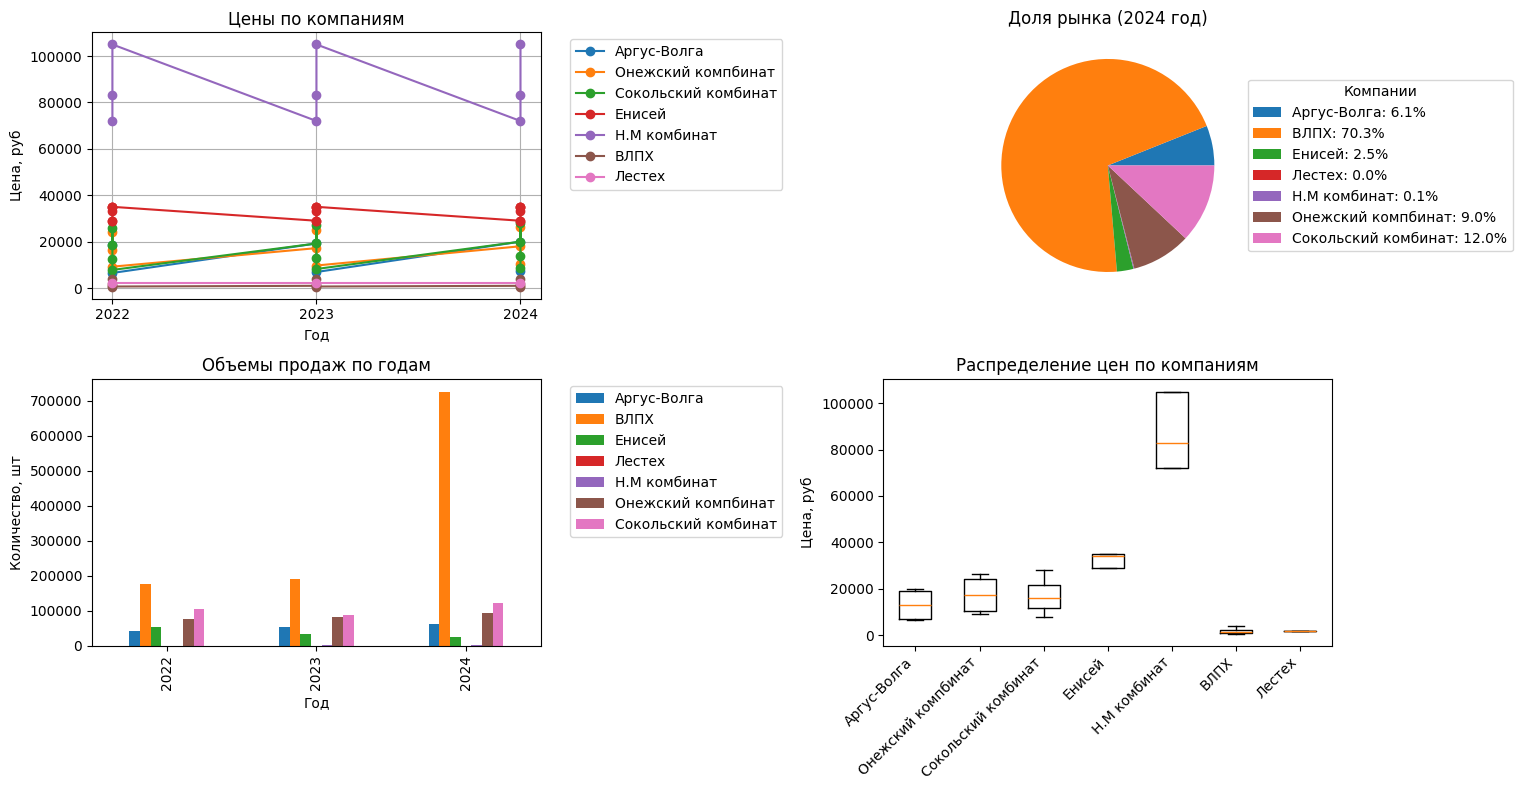

Средняя цена: 26,579 руб
Общий объем: 1,935,284 шт
Общая выручка: 17,063,443,112 руб

Топ компаний по объему:
  ВЛПХ: 1,091,709 шт
  Сокольский комбинат: 318,687 шт
  Онежский компбинат: 250,064 шт


In [21]:
key_products = ['брус']

for product in key_products:
    product_data = analyze_product_sales(product)
    if product_data is not None:
        analyzer.plot_product_analysis(product)